# Notebook 01 — SimpleMLP 784→8→4→2 on MNIST even/odd (digits 0, 1, 3, 4)

**Architecture:** SimpleMLP with hidden dims [8, 4], trained on MNIST digits 0, 1, 3, 4 with even/odd binary labels.

## Structure
0. **Imports & setup**
1. **Configuration**
2. **Backward Factor Trace** — seed-0 model, BFT, exploratory plots (pixel receptive fields, scaffold graphs)
3. **BFT figures** — main-paper figure 2 and its appendix companion
4. **Fingerprints** — NNLS factor tree, fingerprint similarity, near-OOD (excluded digits), far-OOD (synthetic)
5. **Fingerprint figures** — main paper and appendix (placeholders)

Validation, robustness and ablation analyses live in notebook 09.

## §0 — Imports & setup

In [ ]:
#%matplotlib inline
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor

from src import (
    SimpleMLP, load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs_generic, collect_layer_dicts, bft, evaluate, build_scaffold_edges,
    scaffold_loading_from_edges, plot_scaffold_graph, extract_tree_nodes,
    extract_factor_tree_nodes, extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree, compute_factor_activations, plot_factor_tree,
    plot_input_layer_factors, plot_embedding_comparison, save_experiment,
)
from src.training import train_epoch, label_transform_even_odd
from src.data_utils import get_mnist_loaders, label_transformed_loader

matplotlib.rcParams.update({'figure.dpi': 80})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

## §1 — Configuration

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)

MODEL_ROOT = os.path.join(_repo_dir, 'data', 'models')
FIG_DIR    = os.path.join(_repo_dir, 'figs', '01_mlp_8_4_0134')
for d in [MODEL_ROOT, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Experiment ────────────────────────────────────────────────────────────────
EXP_BASE     = 'mnist_even_odd_mlp_8_4_0134'
N_EPOCHS     = 30
DIGIT_FILTER = [0, 1, 3, 4]
N_CLASSES    = 2
CLASS_NAMES  = {0: 'even', 1: 'odd'}
IMAGE_SIDE   = 28

BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [8, 4], 'output_dim': 2},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 32,
                       'digit_filter': DIGIT_FILTER},
    'label_transform': 'even_odd',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}

# ── BFT config — PUBLICATION SETTINGS (see PUBLICATION_SETTINGS.md) ───────────
# From the nb09 S10 sweep (`rank x0.7`, run 4). The sweep passed [4, 1, 1], but bft's
# _auto_k_factorize floors k_max at 2 (`max(int(k_max), 2)`), so 1 and 2 behave identically
# here -- verified bit-identical fingerprints. [4, 2, 2] is written instead because it is
# what actually executes.
#
# Net effect vs the old [5, 5, 5]: ONLY the input layer changes (rank 5 -> 4). The root and
# hidden layers already auto-selected K = 2 / 1 / 2 and are untouched. Measured:
#   silhouette  0.666 -> 0.711     fingerprint  15 -> 13 dims
#   median causal R2  0.968 -> 0.955   BUT worst-node R2  0.778 -> 0.838 (improves)
N_BRANCHES         = [1, 1, 2]
K_MAX_PER_LAYER    = [4, 2, 2]
STIMULUS_THRESHOLD = 0.5
# Causal-validation sample count. The default (100) is what produced the spurious
# R2 = -0.484 input node; at 2000 the same node reconstructs at +0.778.
VALIDATE_TOP_M     = 2000

# ── Fingerprint / OOD config (§4) ─────────────────────────────────────────────
N_FAR_OOD = 300

print(f'MODEL_ROOT: {MODEL_ROOT}')
print(f'FIG_DIR:    {FIG_DIR}')

## §2 — Backward Factor Trace (seed 0)

### 2a — Model, loaders and layer activations

In [ ]:
# ── Seed-0 model: load or train ───────────────────────────────────────────────
exp_dir = os.path.join(MODEL_ROOT, f'{EXP_BASE}_seed0')

if os.path.exists(os.path.join(exp_dir, 'weights.pt')):
    model, config = load_experiment(exp_dir, DEVICE)
    print(f'Loaded model from {exp_dir}')
else:
    print('No checkpoint found, training from scratch...')
    torch.manual_seed(0)
    np.random.seed(0)
    model  = SimpleMLP(**BASE_CONFIG['arch_kwargs']).to(DEVICE)
    config = dict(BASE_CONFIG, description=f'{EXP_BASE} seed 0')

    _train_loader, _ = get_mnist_loaders(batch_size=32, root='../data/',
                                         digit_filter=DIGIT_FILTER)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    for ep in range(N_EPOCHS):
        train_epoch(model, _train_loader, optimizer, criterion, DEVICE,
                    label_transform_even_odd)
    save_experiment(model, config, exp_dir)
    print(f'Saved to {exp_dir}')

train_loader, test_loader = get_loaders_from_config(config)
label_transform = get_transform(config['label_transform'])
digit_filter    = config['dataset_kwargs']['digit_filter']
_, test_acc     = evaluate(model, test_loader, nn.CrossEntropyLoss(), DEVICE, label_transform)

linear_indices = model.linear_layer_indices()
LAYER_SIZES    = [model.layers[li].out_features for li in linear_indices]
print(f'Seed-0 test accuracy: {test_acc:.4f}')
print(f'Architecture (per-layer neurons): {LAYER_SIZES}')

In [4]:
from src.data_utils import label_transformed_loader

# Loader yielding even/odd labels, for BFT primary mode (enables validate=True).
val_loader = label_transformed_loader(test_loader, label_transform)

# Collect the SAME samples BFT primary mode uses (loader order, only_correct), so
# downstream per-sample arrays stay aligned with tree_root's img_factors.
_collected  = collect_layer_dicts(model, test_loader, label_transform=label_transform,
                                  device=DEVICE)
all_images   = _collected['images']                              # (N, 1, 28, 28)
all_targets  = _collected['targets']                             # (N,) even/odd labels
all_digits   = _collected['digits']                              # (N,) original digit
layer_inputs = [d['input_fmap'] for d in _collected['layer_data']]  # list[(N, n_in)]
n_samples    = len(all_images)
flat_imgs    = all_images.reshape(n_samples, -1)

print(f'Samples: {n_samples}')
print(f'Class distribution: {dict(zip(*np.unique(all_targets, return_counts=True)))}')
for i, li in enumerate(layer_inputs):
    print(f'  L{i+1} inputs: {li.shape}')

Samples: 4080
Class distribution: {np.int64(0): np.int64(1953), np.int64(1): np.int64(2127)}
  L1 inputs: (4080, 784)
  L2 inputs: (4080, 8)
  L3 inputs: (4080, 4)


### 2b — Run BFT

In [5]:

# Primary mode: pass (model, loader) so BFT collects internally and validate=True works.
tree_root = bft(
    model, val_loader,
    k_max=K_MAX_PER_LAYER,
    n_branches=N_BRANCHES,
    stimulus_threshold=STIMULUS_THRESHOLD,
    weighting='img_selectivity',
    validate=True,
    validate_top_m=VALIDATE_TOP_M,
    verbose=1,
    n_jobs=3,
)
print('Validation summary:', tree_root.validation_summary())


def get_nodes_by_depth(root):
    from collections import deque
    by_depth = {}
    queue = deque([(root, 0)])
    while queue:
        node, d = queue.popleft()
        by_depth.setdefault(d, []).append(node)
        for child in node.children:
            queue.append((child, d+1))
    return by_depth

def get_all_paths(root):
    if not root.children: return [[root]]
    return [[root] + p for child in root.children for p in get_all_paths(child)]

nodes_by_depth = get_nodes_by_depth(tree_root.root)
all_paths      = get_all_paths(tree_root.root)
print(f'Tree: {len(nodes_by_depth)} depths, {sum(len(v) for v in nodes_by_depth.values())} nodes, {len(all_paths)} paths')

[BFT] Layer 3/3 'layers.5' (fc)  path=[]
[BFT L3 'layers.5' (fc)]   K=2  t=0.030s
[BFT L3 'layers.5' (fc)]   recon: preact_R2=0.981  abs_CE_gap=0.0004  ratio_floored=0.075  (raw=1.926, n_eval=4080)
[BFT] Layer 2/3 'layers.3' (fc)  path=[0]
[BFT L2 'layers.3' (fc)]   K=1  t=0.015s
[BFT L2 'layers.3' (fc)]   recon: preact_R2=0.981  abs_CE_gap=0.0000  ratio_floored=0.007  (raw=2.822, n_eval=100)
[BFT] Layer 1/3 'layers.1' (fc)  path=[0, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 'layers.1' (fc)]   K=5  t=27.486s
[BFT L1 'layers.1' (fc)]   recon: preact_R2=0.947  abs_CE_gap=-0.0000  ratio_floored=0.002  (raw=0.895, n_eval=100)
[BFT] Layer 2/3 'layers.3' (fc)  path=[1]
[BFT L2 'layers.3' (fc)]   K=2  t=0.017s
[BFT L2 'layers.3' (fc)]   recon: preact_R2=0.994  abs_CE_gap=0.0000  ratio_floored=0.004  (raw=1.018, n_eval=100)
[BFT] Layer 1/3 'layers.1' (fc)  path=[1, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 'layers.1' (fc)]   K=5  t=28.001s
[BFT L1 'layers.1' (fc)]   recon: preact_R2=-0.484  abs_CE_gap=6.1841  ratio_floored=618.522  (raw=5287.938, n_eval=100)
Validation summary: {'overall': {'loss_ratio_floored': {'n': 5, 'mean': 123.72193029012222, 'median': 0.006676703691482544, 'min': 0.002273823833093047, 'max': 618.5220947265625, 'std': 247.40008372558657}, 'abs_ce_gap': {'n': 5, 'mean': 1.2368903010103158, 'median': 4.311078460887074e-05, 'min': -2.6596989482641202e-06, 'max': 6.184051262512804, 'std': 2.473580484421254}, 'preact_r2': {'n': 5, 'mean': 0.6836696697122464, 'median': 0.9806072163623307, 'min': -0.4840818111039702, 'max': 0.9938837288068572, 'std': 0.5840805749434835}, 'loss_ratio_all': {'n': 5, 'mean': 1058.9198920791546, 'median': 1.925711615108519, 'min': 0.8952789386387341, 'max': 5287.938423018231, 'std': 2114.5093798707976}}, 'per_layer': {0: {'loss_ratio_floored': {'n': 2, 'mean': 309.2621842751978, 'median': 309.2621842751978, 'min': 0.002273823833093047

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


### 2c — Exploratory plots: input-layer pixel receptive fields

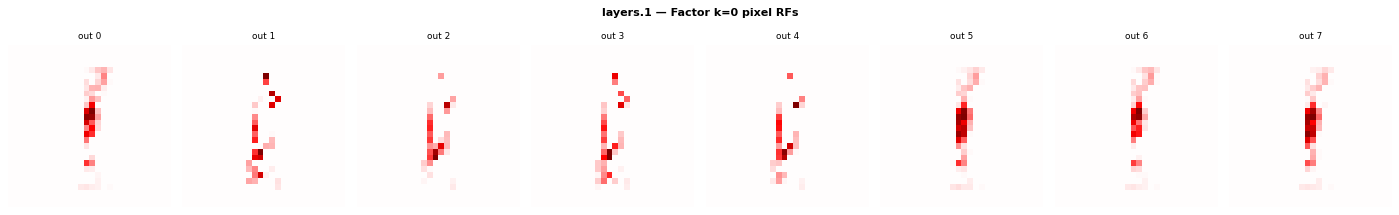

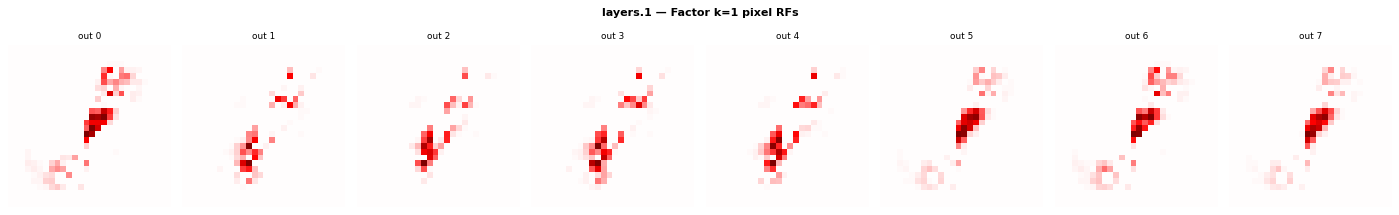

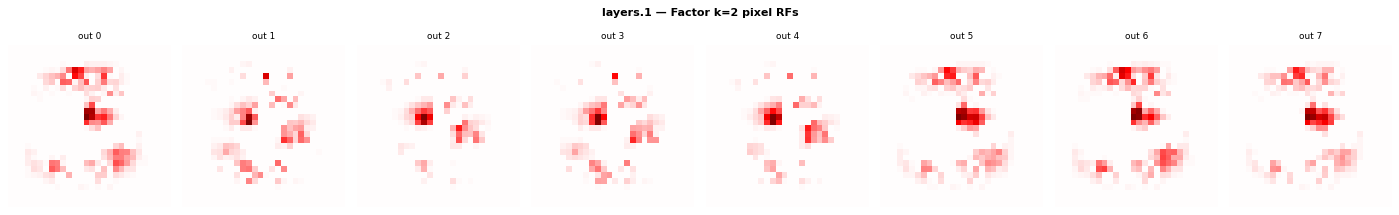

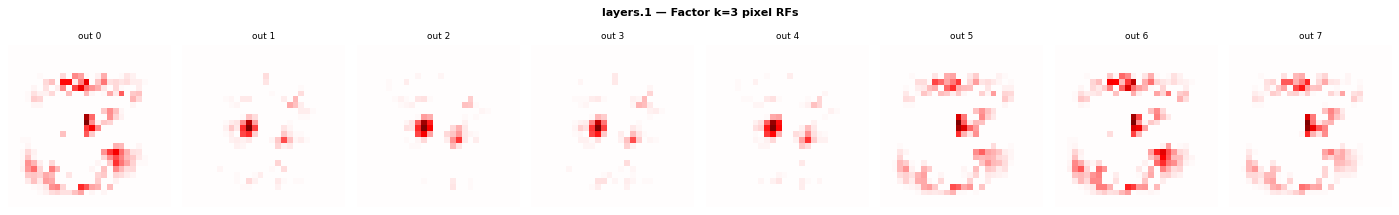

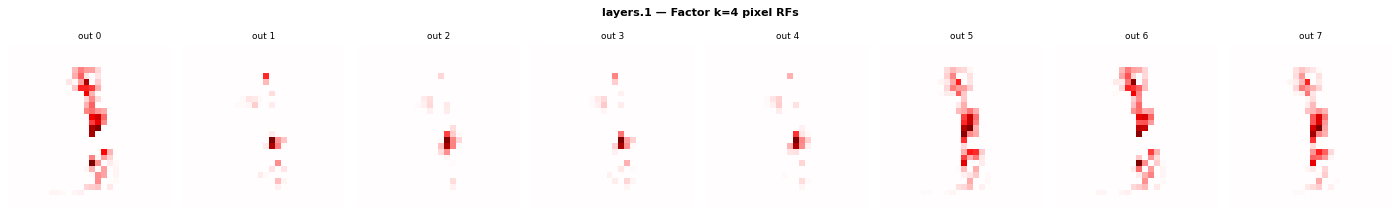

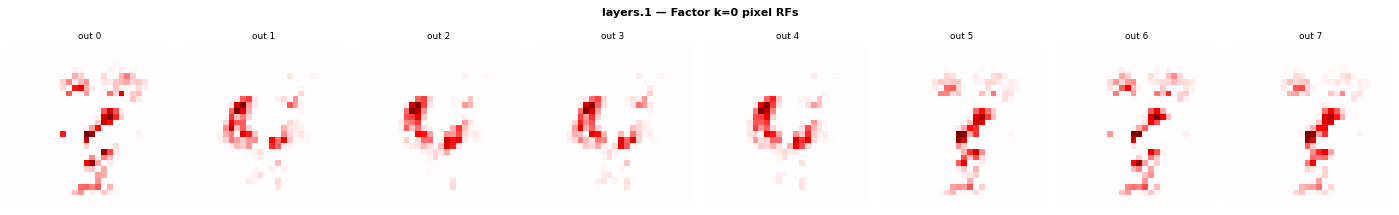

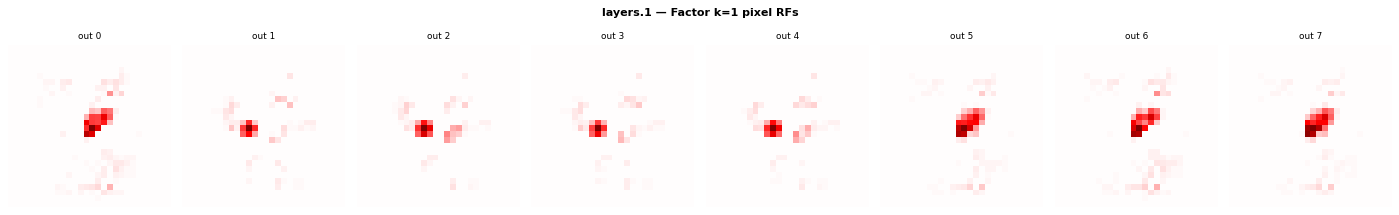

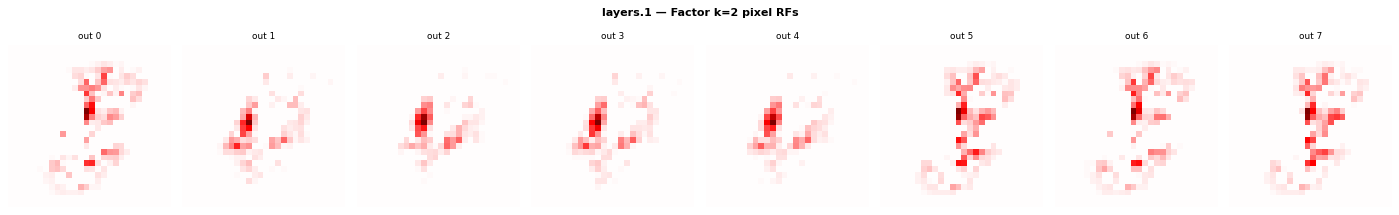

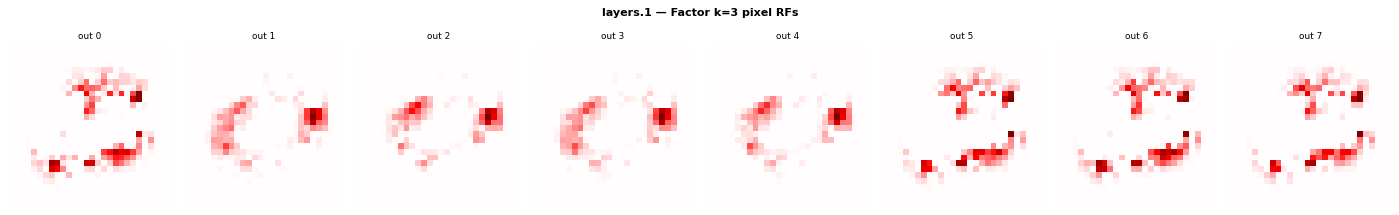

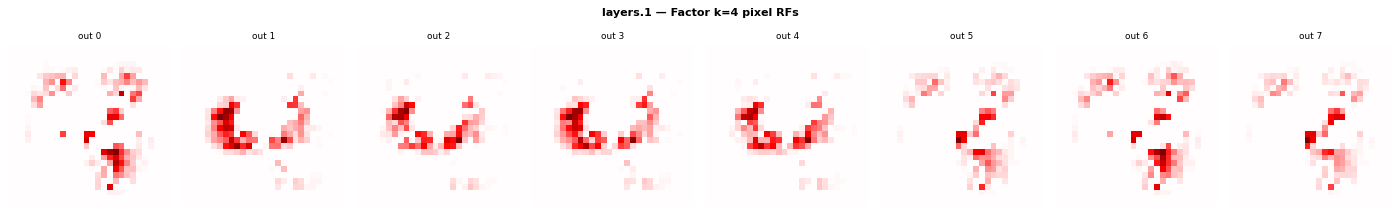

In [7]:
# ── Plot 2: Input-layer pixel receptive fields ────────────────────────────────
# Shows connection_factors[:, k] for each L1 node reshaped to (n_out, 28, 28)
max_depth = max(nodes_by_depth.keys())
for r in nodes_by_depth[max_depth]:
    path_label = 'F' + '→F'.join(str(f) for f in r.path) if r.path else 'root'
    figs = plot_input_layer_factors(
        r, all_images, arch='fc', image_shape=(IMAGE_SIDE, IMAGE_SIDE)
    )
    for k, fig in enumerate(figs):
        fname = f"pixel_rf_L{r.layer_idx+1}_{path_label.replace('→','-')}_k{k}.pdf"
        fig.savefig(os.path.join(FIG_DIR, fname), bbox_inches='tight')
        plt.show(); plt.close(fig)


### 2d — Exploratory plots: full-network scaffold graphs

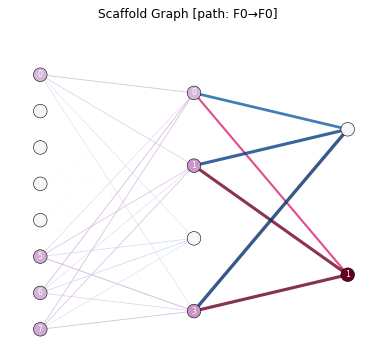

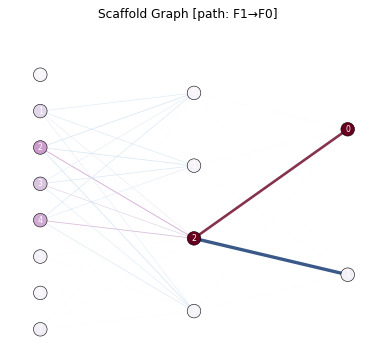

In [8]:
for path_nodes in all_paths:
    layer_results = list(reversed(path_nodes))  # L1-first order

    edge_matrices, neg_edge_matrices = build_scaffold_edges(
        layer_results[1:], fi='path', fi_seed=layer_results[0], top_pct=0.05,
    )
    loading = scaffold_loading_from_edges(edge_matrices)

    path_label = 'F' + '→F'.join(str(f) for f in path_nodes[-1].path)

    fig = plot_scaffold_graph(loading, edge_matrices, LAYER_SIZES,
                              neg_edge_matrices=neg_edge_matrices)
    fig.suptitle(f'Scaffold Graph [path: {path_label}]', fontsize=11)

    _pl = path_label.replace('→', '-')
    fig.savefig(os.path.join(FIG_DIR, f'scaffold_{_pl}.pdf'), bbox_inches='tight')
    plt.show()


## §3 — BFT figures (main paper & appendix)

### 3a — Main-paper figure 2 — class and sub-class circuits

[check:fig2_mlp_circuits] OK: no layout problems detected
[check:fig2_mlp_circuits] info: content/canvas coverage: 99%
[check:fig2_mlp_circuits] info: axes[7] has no data (intended?)
[check:fig2_mlp_circuits] NOTE: automated checks are incomplete — always view the preview PNG and judge readability and message clarity visually.
[figstyle] saved /Users/johannesbertram/repos/Weight_Interpretability/figures/fig2_mlp_circuits.pdf (+ preview/fig2_mlp_circuits.png)


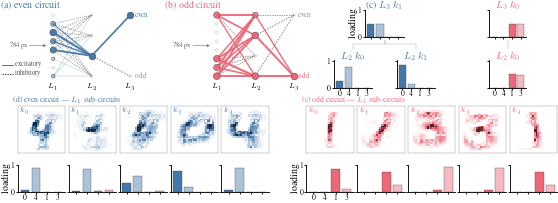

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER FIGURE 2 (main text, full width) — class and sub-class circuits in the MLP
# Requires: tree_root, all_digits, LAYER_SIZES  (§2 above)
# Writes:   figures/fig2_mlp_circuits.pdf  (+ figures/preview/*.png)
# Note: figstyle.apply() sets rcParams globally for the rest of the session.
# ═══════════════════════════════════════════════════════════════════════════════
import figstyle          # repo root; styling + venue geometry for AAAI

DIGIT_ORDER = [0, 4, 1, 3]          # even digits first, then odd
IMAGE_SIDE  = 28

C_EVEN, C_ODD = figstyle.color('even'), figstyle.color('odd')
C_INH = figstyle.color('inhibitory')


def _tint(hex_color, amount):
    """Blend a color toward white (0 keeps it, 1 makes it white)."""
    rgb = np.array(matplotlib.colors.to_rgb(hex_color))
    return tuple(rgb + (1.0 - rgb) * amount)


DIGIT_COLOR = {0: C_EVEN, 4: _tint(C_EVEN, 0.55),
               1: C_ODD,  3: _tint(C_ODD, 0.55)}


def _class_cmap(hex_color, name):
    """white -> class color -> near-black sequential map (keeps class identity)."""
    rgb = np.array(matplotlib.colors.to_rgb(hex_color))
    return matplotlib.colors.LinearSegmentedColormap.from_list(
        name, [(1, 1, 1), tuple(rgb + (1 - rgb) * 0.45), tuple(rgb), tuple(rgb * 0.35)])


def digit_loading(node, k, digits, digit_order=DIGIT_ORDER):
    """Share of factor k's mean stimulus loading contributed by each digit."""
    col = node.img_factors[:, k]
    m = np.array([col[digits == d].mean() for d in digit_order])
    return m / (m.sum() + 1e-12)


def bar_panel(ax, node, k, digits, *, xticks=True, yticklabels=False, ylab=None,
              title=None, tcolor='k'):
    """Mini bar chart: per-digit share of one factor's stimulus loading."""
    v = digit_loading(node, k, digits)
    ax.bar(np.arange(len(DIGIT_ORDER)), v,
           color=[DIGIT_COLOR[d] for d in DIGIT_ORDER],
           edgecolor='0.25', linewidth=0.3, width=0.8)
    ax.set_xlim(-0.65, len(DIGIT_ORDER) - 0.35)
    ax.set_ylim(0, 1.02)
    ax.set_xticks(np.arange(len(DIGIT_ORDER)))
    ax.set_xticklabels(DIGIT_ORDER if xticks else [])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'] if (yticklabels or ylab) else [])
    ax.tick_params(length=1.5, pad=1)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    if ylab:
        ax.set_ylabel(ylab, labelpad=1)
    if title:
        ax.set_title(title, color=tcolor, pad=1.5)


def pixel_arbor(node, k):
    """Pixel-space arbor of factor k: connection mass per input pixel."""
    n_out, n_in = node.weight.shape
    return node.connection_factors[:, k].reshape(n_out, n_in).sum(0).reshape(
        IMAGE_SIDE, IMAGE_SIDE)


def draw_scaffold(ax, edges, neg_edges, loading, layer_sizes, color,
                  out_labels=('even', 'odd'), highlight_out=0, legend=False):
    """Neuron-level circuit graph L1 -> L2 -> L3, excitatory and inhibitory edges."""
    ys = [np.linspace(0.98, 0.02, n) if n > 1 else np.array([0.5]) for n in layer_sizes]
    xs = [np.full(n, float(li)) for li, n in enumerate(layer_sizes)]
    off = np.cumsum([0] + list(layer_sizes))
    load = np.asarray(loading, float)

    for bi, (E, N) in enumerate(zip(edges, neg_edges)):
        emax = max(E.max(), N.max(), 1e-12)              # per-boundary normalization
        for M, col, lsty, z, al, sc in ((N, C_INH, (0, (1.4, 1.1)), 1, .55, 0.9),
                                        (E, color, '-', 2, .95, 1.8)):
            for i in range(M.shape[0]):
                for j in range(M.shape[1]):
                    w = M[i, j] / emax
                    if w < 0.03:
                        continue
                    ax.plot([xs[bi][j], xs[bi + 1][i]], [ys[bi][j], ys[bi + 1][i]],
                            lw=0.12 + sc * w, color=col, linestyle=lsty,
                            alpha=al, zorder=z, solid_capstyle='round')

    for li, n in enumerate(layer_sizes):
        v = load[off[li]:off[li + 1]]
        v = v / (v.max() + 1e-12)                        # per-layer normalization
        on = v >= 0.05
        ax.scatter(xs[li][on], ys[li][on], s=7 + 30 * v[on],
                   c=[matplotlib.colors.to_rgba(color, 0.3 + 0.7 * vi) for vi in v[on]],
                   edgecolors='0.25', linewidths=0.4, zorder=3)
        ax.scatter(xs[li][~on], ys[li][~on], s=6, c='none',
                   edgecolors='0.72', linewidths=0.4, zorder=3)

    ax.annotate('', xy=(-0.18, 0.5), xytext=(-0.62, 0.5),
                arrowprops=dict(arrowstyle='-|>', lw=0.5, color='0.45',
                                shrinkA=0, shrinkB=0, mutation_scale=5))
    ax.text(-0.66, 0.5, '784 px', ha='right', va='center', fontsize=6, color='0.35')
    for li, lab in enumerate([r'$L_1$', r'$L_2$', r'$L_3$']):
        ax.text(li, -0.10, lab, ha='center', va='top', fontsize=6.5)
    for i, lab in enumerate(out_labels):
        ax.text(2.12, ys[2][i], lab, ha='left', va='center', fontsize=6.5,
                color=color if i == highlight_out else '0.55',
                fontweight='bold' if i == highlight_out else 'normal')
    if legend:
        for yy, (col, lsty, lab) in enumerate(((color, '-', 'excitatory'),
                                               (C_INH, (0, (1.4, 1.1)), 'inhibitory'))):
            y = 0.20 - 0.14 * yy
            ax.plot([-1.33, -1.05], [y, y], color=col, linestyle=lsty, lw=0.9,
                    solid_capstyle='round')
            ax.text(-1.0, y, lab, fontsize=6.2, ha='left', va='center', color='0.3')
    ax.set_xlim(-1.35, 2.8)
    ax.set_ylim(-0.2, 1.06)
    ax.axis('off')


# ── index the trace tree; identify the even / odd root factor from the data ──
root = tree_root.root
by_path = {}


def _walk(n):
    by_path[tuple(n.path)] = n
    for ch in n.children:
        _walk(ch)


_walk(root)

_even_cols = [i for i, d in enumerate(DIGIT_ORDER) if d % 2 == 0]
root_even_k = int(np.argmax([digit_loading(root, k, all_digits)[_even_cols].sum()
                             for k in range(root.img_factors.shape[1])]))
CIRCUITS = [dict(name='even', k=root_even_k,     color=C_EVEN),
            dict(name='odd',  k=1 - root_even_k, color=C_ODD)]
for c in CIRCUITS:
    c['l2'] = by_path[(c['k'],)]
    c['l1'] = by_path[(c['k'], 0)]
    path_nodes = [root, c['l2'], c['l1']]                       # root-first
    layer_results = list(reversed(path_nodes))                  # L1-first
    E, negE = build_scaffold_edges(layer_results[1:], fi='path',
                                   fi_seed=layer_results[0], top_pct=0.05)
    c['scaffold'] = dict(edges=E, neg_edges=negE,
                         loading=scaffold_loading_from_edges(E))

OUT_LABELS = ('even', 'odd')          # output-unit order: class 0 = even

# ── figure ──────────────────────────────────────────────────────────────────
figstyle.apply(venue='aaai2024', width='full', nrows=2, ncols=3, mode='paper',
               height_to_width_ratio=0.545)
fig = plt.figure()
# NOTE: wspace/hspace must not be passed to subgridspec() (silently disables
# constrained_layout in mpl 3.10) — inner spacing is set on the layout engine.
fig.set_layout_engine('constrained', h_pad=0.012, w_pad=0.012,
                      hspace=0.03, wspace=0.02)
gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.0, 1.45],
                      height_ratios=[1.0, 1.32], hspace=0.14)

# (a), (b) — neuron-level circuits
for i, c in enumerate(CIRCUITS):
    ax = fig.add_subplot(gs[0, i])
    draw_scaffold(ax, c['scaffold']['edges'], c['scaffold']['neg_edges'],
                  c['scaffold']['loading'], LAYER_SIZES, c['color'],
                  out_labels=OUT_LABELS, highlight_out=i, legend=(i == 0))
    ax.set_title(f"({'ab'[i]}) {c['name']} circuit", color=c['color'], pad=2, loc='left')

# (c) — output- and middle-layer factors, laid out as the top of the trace tree
gsc = gs[0, 2].subgridspec(3, 8, height_ratios=[1.0, 0.22, 1.0])
ax_c = [fig.add_subplot(gsc[0, 1:3]), fig.add_subplot(gsc[0, 5:7]),
        fig.add_subplot(gsc[2, 0:2]), fig.add_subplot(gsc[2, 2:4]),
        fig.add_subplot(gsc[2, 5:7])]
fig.add_subplot(gsc[1, :]).set_axis_off()          # room for the tree connectors
bar_panel(ax_c[0], root, CIRCUITS[0]['k'], all_digits, xticks=False, ylab='loading',
          title=rf"(c) $L_3\ k_{{{CIRCUITS[0]['k']}}}$", tcolor=C_EVEN)
bar_panel(ax_c[1], root, CIRCUITS[1]['k'], all_digits, xticks=False,
          title=rf"$L_3\ k_{{{CIRCUITS[1]['k']}}}$", tcolor=C_ODD)
bar_panel(ax_c[2], CIRCUITS[0]['l2'], 0, all_digits, yticklabels=True,
          title=r'$L_2\ k_0$', tcolor=C_EVEN)
bar_panel(ax_c[3], CIRCUITS[0]['l2'], 1, all_digits, title=r'$L_2\ k_1$', tcolor=C_EVEN)
bar_panel(ax_c[4], CIRCUITS[1]['l2'], 0, all_digits, title=r'$L_2\ k_0$', tcolor=C_ODD)

# (d), (e) — layer-1 sub-circuits: pixel-space arbor + per-digit loading
gs_bot = gs[1, :].subgridspec(2, 1, height_ratios=[0.13, 1.0])
sp_de = fig.add_subplot(gs_bot[0]); sp_de.set_axis_off()   # room for the block labels
gsd = gs_bot[1].subgridspec(2, 11, height_ratios=[1.0, 0.45],
                            width_ratios=[1] * 5 + [0.4] + [1] * 5)
img_axes = {}
for ci, c in enumerate(CIRCUITS):
    node, base = c['l1'], (0 if ci == 0 else 6)
    cmap = _class_cmap(c['color'], c['name'])
    img_axes[ci] = []
    for k in range(node.img_factors.shape[1]):
        M = pixel_arbor(node, k)
        axi = fig.add_subplot(gsd[0, base + k])
        axi.imshow(M, cmap=cmap, interpolation='nearest',
                   norm=matplotlib.colors.PowerNorm(0.62, vmin=0,
                                                    vmax=np.percentile(M, 99.3)))
        axi.set_xticks([]); axi.set_yticks([])
        for s in axi.spines.values():
            s.set_color('0.6'); s.set_linewidth(0.4)
        axi.text(0.05, 0.97, rf'$k_{k}$', transform=axi.transAxes, ha='left',
                 va='top', color=c['color'], fontsize=6.5)
        img_axes[ci].append(axi)
        bar_panel(fig.add_subplot(gsd[1, base + k]), node, k, all_digits,
                  xticks=(k == 0), ylab='loading' if k == 0 else None)

# ── settle constrained_layout, then freeze and add cross-axes annotation ────
figstyle.freeze(fig)          # draw once, then switch the layout engine off

for src, dsts in ((ax_c[0], (ax_c[2], ax_c[3])), (ax_c[1], (ax_c[4],))):   # tree edges
    b0 = src.get_position()
    x0, ytop = b0.x0 + b0.width / 2, b0.y0 - 0.012
    for d in dsts:
        b1 = d.get_position()
        x1, ybot = b1.x0 + b1.width / 2, b1.y1 + 0.058
        ymid = (ytop + ybot) / 2
        fig.add_artist(matplotlib.lines.Line2D([x0, x0, x1, x1],
                                               [ytop, ymid, ymid, ybot],
                                               color='0.65', lw=0.4, zorder=0))

for ci, c in enumerate(CIRCUITS):                                          # block labels
    fig.text(max(img_axes[ci][0].get_position().x0 - 0.008, 0.002),
             sp_de.get_position().y0,
             f"({'de'[ci]}) {c['name']} circuit — $L_1$ sub-circuits",
             ha='left', va='bottom', color=c['color'])

figstyle.save_fig(fig, 'fig2_mlp_circuits')
plt.show()

### 3b — Appendix figure — decomposition details

[check:figA_mlp_details] OK: no layout problems detected
[check:figA_mlp_details] info: content/canvas coverage: 99%
[check:figA_mlp_details] info: axes[0] has no data (intended?)
[check:figA_mlp_details] info: axes[1] has no data (intended?)
[check:figA_mlp_details] info: axes[2] has no data (intended?)
[check:figA_mlp_details] info: axes[8] has no data (intended?)
[check:figA_mlp_details] info: axes[9] has no data (intended?)
[check:figA_mlp_details] info: axes[18] has no data (intended?)
[check:figA_mlp_details] info: axes[27] has no data (intended?)
[check:figA_mlp_details] info: axes[36] has no data (intended?)
[check:figA_mlp_details] info: axes[37] has no data (intended?)
[check:figA_mlp_details] NOTE: automated checks are incomplete — always view the preview PNG and judge readability and message clarity visually.
[figstyle] saved /Users/johannesbertram/repos/Weight_Interpretability/figures/appendix/figA_mlp_details.pdf (+ preview/figA_mlp_details.png)


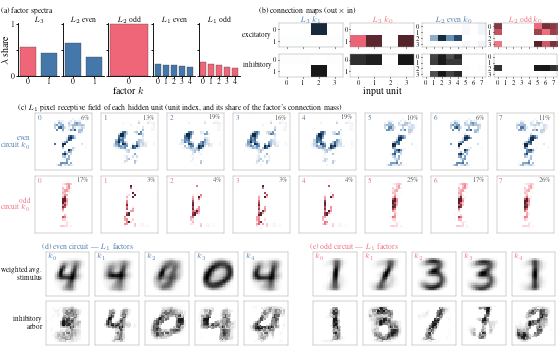

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER APPENDIX FIGURE — decomposition details for the 8x4 MLP
# Requires: the main-figure cell above (shared helpers, CIRCUITS, root) + all_images
# Writes:   figures/appendix/figA_mlp_details.pdf  (+ preview PNG)
# ═══════════════════════════════════════════════════════════════════════════════
CMAP_INH = _class_cmap(C_INH, 'inh')


def _show_map(ax, M, cmap, pct=99.3, gamma=0.62):
    ax.imshow(M, cmap=cmap, interpolation='nearest',
              norm=matplotlib.colors.PowerNorm(gamma, vmin=0,
                                               vmax=np.percentile(M, pct)))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color('0.6'); s.set_linewidth(0.4)


def _row_label(fig, spec, text, color='k'):
    """Axis-off cell used as a row label (keeps the image grid perfectly aligned)."""
    ax = fig.add_subplot(spec)
    ax.set_axis_off()
    ax.text(1.0, 0.5, text, transform=ax.transAxes, ha='right', va='center',
            color=color, fontsize=6.5)
    return ax


anchors = {}
figstyle.apply(venue='aaai2024', width='full', nrows=3, ncols=3, mode='appendix',
               height_to_width_ratio=0.62)
fig = plt.figure()
fig.set_layout_engine('constrained', h_pad=0.012, w_pad=0.012, hspace=0.03, wspace=0.02)
# rows 0/2/4 are thin spacers that reserve room for the panel labels, which are
# placed after the layout is frozen (a long label inside an axes would inflate
# that grid cell and squeeze the image rows).
gs = fig.add_gridspec(6, 1, height_ratios=[0.10, 0.60, 0.10, 0.90, 0.11, 0.70],
                      hspace=0.03)
spacers = [fig.add_subplot(gs[r]) for r in (0, 2, 4)]
for sp in spacers:
    sp.set_axis_off()
gs_top = gs[1].subgridspec(1, 2, width_ratios=[1.0, 1.32])

# ── (a) lambda spectrum of every node in the trace ──────────────────────────
gsa = gs_top[0, 0].subgridspec(1, 5)
nodes_a = [('$L_3$', root, [CIRCUITS[1]['color'], CIRCUITS[0]['color']]),
           ('$L_2$ even', CIRCUITS[0]['l2'], [C_EVEN] * 5),
           ('$L_2$ odd',  CIRCUITS[1]['l2'], [C_ODD] * 5),
           ('$L_1$ even', CIRCUITS[0]['l1'], [C_EVEN] * 5),
           ('$L_1$ odd',  CIRCUITS[1]['l1'], [C_ODD] * 5)]
for i, (name, node, cols) in enumerate(nodes_a):
    ax = fig.add_subplot(gsa[0, i])
    lam = node.lambdas / node.lambdas.sum()
    ax.bar(np.arange(len(lam)), lam, color=cols[:len(lam)], edgecolor='0.25',
           linewidth=0.3, width=0.75)
    ax.set_xticks(np.arange(len(lam)))
    ax.set_xticklabels(np.arange(len(lam)))
    ax.set_ylim(0, 1.02)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(['0', '', '1'] if i == 0 else [])
    ax.tick_params(length=1.5, pad=1)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    ax.set_title(name, pad=1.5, fontsize=7)
    if i == 2:
        ax.set_xlabel('factor $k$', labelpad=1)
    if i == 0:
        ax.set_ylabel(r'$\lambda$ share', labelpad=1)
        anchors['a'] = ax

# ── (b) connection maps: excitatory vs inhibitory, L3 and L2 ───────────────
gsb = gs_top[0, 1].subgridspec(2, 5, width_ratios=[0.40] + [1] * 4)
cols_b = [(rf"$L_3\ k_{{{CIRCUITS[0]['k']}}}$", root, CIRCUITS[0]['k'], C_EVEN),
          (rf"$L_3\ k_{{{CIRCUITS[1]['k']}}}$", root, CIRCUITS[1]['k'], C_ODD),
          (r'$L_2$ even $k_0$', CIRCUITS[0]['l2'], 0, C_EVEN),
          (r'$L_2$ odd $k_0$',  CIRCUITS[1]['l2'], 0, C_ODD)]
for r, lab in enumerate(('excitatory', 'inhibitory')):
    _row_label(fig, gsb[r, 0], lab)
for j, (name, node, k, col) in enumerate(cols_b):
    n_out, n_in = node.weight.shape
    for r, (F, cmap) in enumerate(((node.connection_factors, _class_cmap(col, f'c{j}')),
                                   (node.neg_connection_factors, CMAP_INH))):
        ax = fig.add_subplot(gsb[r, j + 1])
        M = F[:, k].reshape(n_out, n_in)
        ax.imshow(M, cmap=cmap, aspect='auto', interpolation='nearest',
                  vmin=0, vmax=M.max() or 1)
        ax.set_xticks(np.arange(n_in)); ax.set_yticks(np.arange(n_out))
        ax.set_xticklabels(np.arange(n_in) if r == 1 else [], fontsize=6)
        ax.set_yticklabels(np.arange(n_out), fontsize=6)
        ax.tick_params(length=1.2, pad=0.8)
        for s in ax.spines.values():
            s.set_color('0.6'); s.set_linewidth(0.4)
        if r == 0:
            ax.set_title(name, color=col, pad=1.5, fontsize=7)
            if j == 0:
                anchors['b'] = ax
        elif j == 1:
            ax.set_xlabel('input unit', labelpad=1)

# ── (c) per-unit pixel receptive fields of the dominant L1 factor ───────────
gsc = gs[3].subgridspec(2, 9, width_ratios=[0.30] + [1] * 8)
for ci, c in enumerate(CIRCUITS):
    node = c['l1']
    n_out, n_in = node.weight.shape
    cf = node.connection_factors[:, 0].reshape(n_out, n_in)
    share = cf.sum(1) / (cf.sum() + 1e-12)
    cmap = _class_cmap(c['color'], f'rf{ci}')
    _row_label(fig, gsc[ci, 0], f"{c['name']}\ncircuit $k_0$", color=c['color'])
    for ni in range(n_out):
        ax = fig.add_subplot(gsc[ci, ni + 1])
        if ci == 0 and ni == 0:
            anchors['c'] = ax
        _show_map(ax, cf[ni].reshape(IMAGE_SIDE, IMAGE_SIDE), cmap, pct=99.5)
        ax.text(0.05, 0.97, f'{ni}', transform=ax.transAxes, ha='left', va='top',
                color=c['color'], fontsize=6.5)
        ax.text(0.95, 0.97, rf'{100 * share[ni]:.0f}\%', transform=ax.transAxes,
                ha='right', va='top', color='0.35', fontsize=6)

# ── (d, e) weighted-average stimulus and inhibitory arbor per L1 factor ────
gsd = gs[5].subgridspec(2, 12, width_ratios=[0.42] + [1] * 5 + [0.4] + [1] * 5)
flat = all_images.reshape(len(all_images), -1)
for r, lab in enumerate(('weighted avg.\nstimulus', 'inhibitory\narbor')):
    _row_label(fig, gsd[r, 0], lab)
first_img = {}
for ci, c in enumerate(CIRCUITS):
    node, base = c['l1'], (1 if ci == 0 else 7)
    for k in range(node.img_factors.shape[1]):
        w = node.img_factors[:, k]
        wavg = (w[:, None] * flat).sum(0) / (w.sum() + 1e-12)
        ax = fig.add_subplot(gsd[0, base + k])
        ax.imshow(wavg.reshape(IMAGE_SIDE, IMAGE_SIDE), cmap='gray_r',
                  interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color('0.6'); s.set_linewidth(0.4)
        ax.text(0.05, 0.97, rf'$k_{k}$', transform=ax.transAxes, ha='left',
                va='top', color=c['color'], fontsize=6.5)
        if k == 0:
            first_img[ci] = ax
        axn = fig.add_subplot(gsd[1, base + k])
        Mn = node.neg_connection_factors[:, k].reshape(
            node.weight.shape).sum(0).reshape(IMAGE_SIDE, IMAGE_SIDE)
        _show_map(axn, Mn, CMAP_INH)

# ── settle constrained_layout, then freeze and add the panel labels ────────
# (long labels must be added after the freeze: inside an axes they would
#  inflate that grid cell and squeeze the image rows)
figstyle.freeze(fig)          # draw once, then switch the layout engine off


def _label(anchor, spacer, text, color='k', dx=0.0):
    fig.text(max(anchor.get_position().x0 + dx, 0.002), spacer.get_position().y0,
             text, ha='left', va='bottom', color=color)


_label(anchors['a'], spacers[0], '(a) factor spectra', dx=-0.030)
_label(anchors['b'], spacers[0], r'(b) connection maps (out $\times$ in)', dx=-0.035)
_label(anchors['c'], spacers[1], '(c) $L_1$ pixel receptive fields', dx=-0.030)
for ci, c in enumerate(CIRCUITS):
    _label(first_img[ci], spacers[2],
           f"({'de'[ci]}) {c['name']} circuit — $L_1$ factors",
           color=c['color'], dx=-0.006)

figstyle.save_fig(fig, 'figA_mlp_details')
plt.show()

## §4 — Fingerprints

In [ ]:
# §3 calls figstyle.apply(), which sets rcParams globally for the rest of the
# session. Reset to the notebook defaults so the exploratory plots below render
# at screen size rather than at venue column width.
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'figure.dpi': 80})

### 4a — NNLS round-trip on the publication factor tree

In [ ]:
# ── Fingerprint basis = the publication tree from §2 ──────────────────────────
# §4 and §5 project new stimuli onto the SAME factors the paper's circuit figure
# shows, so a fingerprint dimension means the same thing as a node in Fig. 2.
# This section used to build a second, wider tree (k_max=[10,1,2],
# n_branches=[8,2,2], stimulus_threshold=0). Measured against it, the publication
# tree is better on every axis: round-trip cosine 0.994 ± 0.040 vs 0.740 ± 0.106,
# even/odd silhouette 0.890 vs 0.617, and 13 dimensions instead of 35.
fp_tree_nodes   = extract_tree_nodes(tree_root)
fp_factor_nodes = extract_factor_tree_nodes(tree_root)

# Round-trip test: NNLS-project the test set back onto the fixed factors and
# compare with the fingerprints the NMF itself produced.
from sklearn.metrics.pairwise import paired_cosine_distances as _pcd
projected_test_rt = project_stimuli_onto_tree(tree_root, layer_inputs)
F_orig  = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
F_rt    = extract_fingerprint_matrix(projected_test_rt, np.arange(n_samples))
rt_sims = 1.0 - _pcd(F_orig, F_rt)
print(f'Round-trip cosine sim: mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')


### 4b — Factor fingerprints & similarity (test set)

In [ ]:
F = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
print(f'Fingerprint matrix: {F.shape}')

MAX_VIZ = 300
viz_idx     = np.argsort(all_targets)[:MAX_VIZ] if n_samples > MAX_VIZ else np.argsort(all_targets)
S           = compute_stimulus_similarity(F[viz_idx])
targets_viz = all_targets[viz_idx]

# ── Similarity heatmap + intra/inter histogram ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(S, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0])
for cl in np.unique(targets_viz):
    for b in np.where(np.diff((targets_viz == cl).astype(int)))[0]:
        axes[0].axhline(b + 0.5, color='k', lw=0.5)
        axes[0].axvline(b + 0.5, color='k', lw=0.5)
axes[0].set(title='Factor fingerprint similarity (sorted by class)',
            xlabel='Stimulus', ylabel='Stimulus')

S_all = compute_stimulus_similarity(F)
classes = sorted(np.unique(all_targets))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask  = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets == cl2)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
axes[1].hist(intra_arr, bins=60, alpha=0.6, density=True,
             label=f'Intra ({intra_arr.mean():.3f})')
axes[1].hist(inter_arr, bins=60, alpha=0.6, density=True,
             label=f'Inter ({inter_arr.mean():.3f})')
axes[1].set(xlabel='Cosine similarity', ylabel='Density',
            title='Intra- vs inter-class fingerprint similarity')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'nnls_fingerprints.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison ───────────────────────────────────────────────
# Panels: PCA(fingerprints) | PCA(last-layer) | PCA(all-layers) | MDS(fingerprints)
full_acts_id = np.concatenate([li[viz_idx] for li in layer_inputs], axis=1)
fig = plot_embedding_comparison(
    F[viz_idx], layer_inputs[-1][viz_idx], targets_viz,
    CLASS_NAMES, digit_targets=all_digits[viz_idx],
    activations_all=full_acts_id,
    title='ID test-set fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_id.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

### 4c — Near-OOD: excluded MNIST digits (2, 5, 6, 7, 8, 9)

In [ ]:
OOD_DIGITS = [d for d in range(10) if d not in digit_filter]
print(f'OOD digits: {OOD_DIGITS}')

mnist_test_full = datasets.MNIST('../data/', train=False, download=True, transform=ToTensor())
ood_labels_all  = np.array(mnist_test_full.targets)
ood_indices     = np.where(np.isin(ood_labels_all, OOD_DIGITS))[0]
ood_subset      = Subset(mnist_test_full, ood_indices)

data_ood = collect_layer_inputs_generic(
    model, ood_subset, label_transform=label_transform_even_odd,
    only_correct=False, device=DEVICE,
)
ood_images  = data_ood['images']
ood_digits  = data_ood['digits']
ood_targets = data_ood['targets']
ood_inputs  = data_ood['layer_inputs']
n_ood       = len(ood_images)
print(f'OOD samples: {n_ood}')

ood_preds        = data_ood['preds']   # what the network says, for §5
projected_ood    = project_stimuli_onto_tree(tree_root, ood_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# ── Factor tree per OOD digit ─────────────────────────────────────────────────
unique_ood = sorted(np.unique(ood_digits))
ncols = min(3, len(unique_ood))
nrows = int(np.ceil(len(unique_ood) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
for i, d in enumerate(unique_ood):
    ax   = axes[i // ncols][i % ncols]
    idx  = np.where(ood_digits == d)[0]
    acts = compute_factor_activations(factor_nodes_ood, idx)
    parity = 'even' if d % 2 == 0 else 'odd'
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'OOD digit {d} ({parity})  n={len(idx)}')
for j in range(len(unique_ood), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)
plt.suptitle('Near-OOD — Factor tree per excluded digit', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'near_ood_tree_per_digit.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison — ID test vs near-OOD ────────────────────────
N_EACH = 150
rng_m  = np.random.default_rng(7)
id_sub  = rng_m.choice(n_samples, min(N_EACH, n_samples), replace=False)
ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)

F_id_sub  = extract_fingerprint_matrix(tree_root, id_sub)
F_ood_sub = extract_fingerprint_matrix(projected_ood, ood_sub)
F_combo   = np.concatenate([F_id_sub, F_ood_sub])
act_combo = np.concatenate([layer_inputs[-1][id_sub], ood_inputs[-1][ood_sub]])
lbl_combo = np.concatenate([all_targets[id_sub], ood_targets[ood_sub]])
digit_combo = np.concatenate([all_digits[id_sub], ood_digits[ood_sub]])
cond_combo  = (['ID'] * len(id_sub)) + (['near-OOD'] * len(ood_sub))

full_id_sub  = np.concatenate([li[id_sub]  for li in layer_inputs], axis=1)
full_ood_sub = np.concatenate([li[ood_sub] for li in ood_inputs],   axis=1)
full_combo   = np.concatenate([full_id_sub, full_ood_sub],           axis=0)

fig = plot_embedding_comparison(
    F_combo, act_combo, lbl_combo,
    CLASS_NAMES, digit_targets=digit_combo,
    condition_labels=cond_combo,
    activations_all=full_combo,
    title='Near-OOD vs ID fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_near_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

### 4d — Far-OOD: synthetic images

In [ ]:
rng_f = np.random.default_rng(99)
_chk  = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR_OOD, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images[:N_FAR_OOD], 0, 1).astype(np.float32),
}

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    ds = TensorDataset(torch.from_numpy(imgs),
                       torch.zeros(len(imgs), dtype=torch.long))
    d = collect_layer_inputs_generic(
        model, ds, label_transform=label_transform_even_odd,
        only_correct=False, device=DEVICE,
    )
    d['projected_root'] = project_stimuli_onto_tree(tree_root, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  model acc={(d["preds"] == d["targets"]).mean():.3f}')

# ── Factor tree per far-OOD type ──────────────────────────────────────────────
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
axes = axes[0]
for ax, (name, d) in zip(axes, far_ood_data.items()):
    acts = compute_factor_activations(d['factor_nodes'], np.arange(len(d['images'])))
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far OOD — factor tree activation per synthetic type', y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.pdf'), bbox_inches='tight')
plt.show()

# ── Plot 7: Embedding comparison — ID / near-OOD / far-OOD ───────────────────
N_MDS = 80
rng_m2 = np.random.default_rng(5)

F_parts, act_parts, full_parts, lbl_parts, digit_parts, cond_parts = [], [], [], [], [], []

# ID test
id_s2 = rng_m2.choice(n_samples, min(N_MDS, n_samples), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root, id_s2))
act_parts.append(layer_inputs[-1][id_s2])
full_parts.append(np.concatenate([li[id_s2] for li in layer_inputs], axis=1))
lbl_parts.append(all_targets[id_s2])
digit_parts.append(all_digits[id_s2])
cond_parts.extend(['ID-test'] * len(id_s2))

# Near-OOD
ood_s2 = rng_m2.choice(n_ood, min(N_MDS, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_s2))
act_parts.append(ood_inputs[-1][ood_s2])
full_parts.append(np.concatenate([li[ood_s2] for li in ood_inputs], axis=1))
lbl_parts.append(ood_targets[ood_s2])
digit_parts.append(ood_digits[ood_s2])
cond_parts.extend(['near-OOD'] * len(ood_s2))

# Far-OOD types
for name, d in far_ood_data.items():
    n  = min(N_MDS, len(d['images']))
    ss = rng_m2.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], ss))
    act_parts.append(d['layer_inputs'][-1][ss])
    full_parts.append(np.concatenate([li[ss] for li in d['layer_inputs']], axis=1))
    lbl_parts.append(d['targets'][ss])
    digit_parts.append(np.full(n, -1))
    cond_parts.extend([name] * n)

F_joint     = np.concatenate(F_parts)
act_joint   = np.concatenate(act_parts)
lbl_joint   = np.concatenate(lbl_parts)
digit_joint = np.concatenate(digit_parts)

fig = plot_embedding_comparison(
    F_joint, act_joint, lbl_joint,
    CLASS_NAMES, digit_targets=None,
    condition_labels=cond_parts,
    far_ood_conditions=list(far_ood_data.keys()),
    activations_all=np.concatenate(full_parts, axis=0),
    title='ID / near-OOD / far-OOD fingerprint embeddings',
)
fig.savefig(os.path.join(FIG_DIR, 'embedding_comparison_all_ood.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig)

## §5 — Fingerprint figures (main paper & appendix)

### 5a — Main-paper figure

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER FIGURE 4 (main text, full width) — factor fingerprints in the 8x4 MLP
# Requires: tree_root, F, all_targets, all_digits  (§2, §4b)
#           projected_ood, ood_digits, ood_preds, n_ood  (§4c)
#           far_ood_data  (§4d)
# Writes:   figures/fig4_mlp_fingerprints.pdf  (+ figures/preview/*.png)
# Note: figstyle.apply() sets rcParams globally for the rest of the session.
# ═══════════════════════════════════════════════════════════════════════════════
import figstyle          # repo root; styling + venue geometry for AAAI
from sklearn.metrics import silhouette_score

DIGIT_ORDER = [0, 4, 1, 3]                       # even digits first, then odd
FAR_LABEL   = {'gaussian_noise': 'noise', 'uniform_gray': 'gray',
               'checkerboard': 'checker', 'inverted_test': 'inverted'}

C_EVEN, C_ODD = figstyle.color('even'), figstyle.color('odd')
C_NEAR, C_FAR, C_ID = (figstyle.color('near_ood'), figstyle.color('far_ood'),
                       figstyle.color('id_data'))


def _tint(hex_color, amount):
    """Blend a color toward white (0 keeps it, 1 makes it white)."""
    rgb = np.array(matplotlib.colors.to_rgb(hex_color))
    return tuple(rgb + (1.0 - rgb) * amount)


DIGIT_COLOR = {0: C_EVEN, 4: _tint(C_EVEN, 0.55),
               1: C_ODD,  3: _tint(C_ODD, 0.55)}


def _class_cmap(hex_color, name):
    """white -> class color -> near-black sequential map (keeps class identity)."""
    rgb = np.array(matplotlib.colors.to_rgb(hex_color))
    return matplotlib.colors.LinearSegmentedColormap.from_list(
        name, [(1, 1, 1), tuple(rgb + (1 - rgb) * 0.45), tuple(rgb), tuple(rgb * 0.35)])


CMAP_EVEN, CMAP_ODD = _class_cmap(C_EVEN, 'ev'), _class_cmap(C_ODD, 'od')
_p = np.array(matplotlib.colors.to_rgb(figstyle.color('ours')))
CMAP_SIM = matplotlib.colors.LinearSegmentedColormap.from_list(     # BFT hue, gentle ramp
    'sim', [(1, 1, 1), tuple(_p + (1 - _p) * 0.78), tuple(_p + (1 - _p) * 0.42),
            tuple(_p), tuple(_p * 0.55)])


def unit(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)


# ── fingerprints of the OOD conditions, on the §2 factors ───────────────────
F_ood = extract_fingerprint_matrix(projected_ood, np.arange(n_ood))
F_far = {name: extract_fingerprint_matrix(d['projected_root'],
                                          np.arange(len(d['images'])))
         for name, d in far_ood_data.items()}

# ── map every fingerprint dim to its (layer, root branch, factor) ───────────
# extract_fingerprint_matrix concatenates nodes in BFS order, so this reproduces
# the column order of F.
_dims, _q = [], [tree_root.root]
while _q:
    _n = _q.pop(0)
    for _k in range(_n.img_factors.shape[1]):
        _dims.append((_n.layer_idx, _n.path[0] if _n.path else -1, _k))
    _q.extend(_n.children)
_dims  = np.array(_dims)
_top   = _dims[:, 0].max()
ROOT_K = np.where(_dims[:, 0] == _top)[0]

# which root factor is the even one (read off the data, as in Fig. 2)
_is_even = all_targets == 0
K_EVEN = int(ROOT_K[np.argmax([F[_is_even, k].mean() - F[~_is_even, k].mean()
                               for k in ROOT_K])])
K_ODD  = int([k for k in ROOT_K if k != K_EVEN][0])


def _circuit_cols(k_root):
    """The fingerprint dims belonging to one root factor's circuit."""
    return [int(k_root)] + [i for i in range(len(_dims))
                            if _dims[i, 0] != _top and _dims[i, 1] == _dims[k_root, 2]]


COLS_EVEN, COLS_ODD = _circuit_cols(K_EVEN), _circuit_cols(K_ODD)
COL_ORDER = COLS_EVEN + COLS_ODD
N_EV = len(COLS_EVEN)


def layer_groups(cols):
    """Contiguous runs of one layer within a column block -> (start, stop, layer)."""
    out, s = [], 0
    for i in range(1, len(cols) + 1):
        if i == len(cols) or _dims[cols[i], 0] != _dims[cols[s], 0]:
            out.append((s, i, int(_dims[cols[s], 0])))
            s = i
    return out


# ── (c) what the fingerprint says vs what the network says ─────────────────
def odd_share(Fm):
    """Share of the two root factors' mass carried by the odd circuit."""
    o, e = Fm[:, K_ODD], Fm[:, K_EVEN]
    return o / (o + e + 1e-12)


ood_pts = [(d, (ood_preds[ood_digits == d] == 1).mean(),
            odd_share(F_ood[ood_digits == d]).mean())
           for d in sorted(np.unique(ood_digits))]
id_pts  = [(d, (all_targets[all_digits == d] == 1).mean(),
            odd_share(F[all_digits == d]).mean()) for d in DIGIT_ORDER]
R_OOD = np.corrcoef([p[1] for p in ood_pts], [p[2] for p in ood_pts])[0, 1]


# ── (d) how tightly each condition's fingerprints cluster ──────────────────
def centroid_cos(Fm):
    """Cosine of every fingerprint to its own condition's mean fingerprint."""
    U = unit(Fm)
    c = U.mean(0)
    return U @ (c / (np.linalg.norm(c) + 1e-12))


COND = ([('ID test', centroid_cos(F), C_ID),
         ('held-out digits', centroid_cos(F_ood), C_NEAR)] +
        [(FAR_LABEL[n], centroid_cos(F_far[n]), C_FAR) for n in far_ood_data])

SIL_CLASS = silhouette_score(unit(F), all_targets, metric='cosine')
SIL_DIGIT = silhouette_score(unit(F), all_digits, metric='cosine')
print(f'fingerprint dim: {F.shape[1]}   silhouette: {SIL_CLASS:.3f} (even/odd), '
      f'{SIL_DIGIT:.3f} (digit)')
print(f'held-out digits: r(odd-circuit share, P(model=odd)) = {R_OOD:.4f}')
for lab, v, _ in COND:
    print(f'  {lab:16s} cos to condition mean: median {np.median(v):.3f}')

# ── figure ──────────────────────────────────────────────────────────────────
figstyle.apply(venue='aaai2024', width='full', nrows=1, ncols=4, mode='paper',
               height_to_width_ratio=0.94)
fig = plt.figure()
# NOTE: wspace/hspace must not be passed to subgridspec() (silently disables
# constrained_layout in mpl 3.10) — inner spacing is set on the layout engine.
fig.set_layout_engine('constrained', h_pad=0.012, w_pad=0.014,
                      hspace=0.02, wspace=0.03)
gs = fig.add_gridspec(2, 4, height_ratios=[0.11, 1.0],
                      width_ratios=[1.28, 1.10, 1.04, 1.14])
sp = fig.add_subplot(gs[0, :]); sp.set_axis_off()      # room for the panel labels

# (a) mean fingerprint per digit, columns grouped by circuit then layer
ax_a = fig.add_subplot(gs[1, 0])
M = np.stack([F[all_digits == d].mean(0) for d in DIGIT_ORDER])
M = M / M.sum(1, keepdims=True)                        # per-digit loading profile
Mo = M[:, COL_ORDER]
_col = np.arange(len(COL_ORDER))
ax_a.imshow(np.where(_col < N_EV, Mo, np.nan), cmap=CMAP_EVEN, vmin=0, vmax=Mo.max(),
            aspect='auto', interpolation='nearest')
ax_a.imshow(np.where(_col >= N_EV, Mo, np.nan), cmap=CMAP_ODD, vmin=0, vmax=Mo.max(),
            aspect='auto', interpolation='nearest')
ax_a.axvline(N_EV - 0.5, color='0.25', lw=0.8)
for off, cols in ((0, COLS_EVEN), (N_EV, COLS_ODD)):
    for s0, s1, lay in layer_groups(cols):
        if s0:
            ax_a.axvline(off + s0 - 0.5, color='0.75', lw=0.4)
        ax_a.text(off + (s0 + s1 - 1) / 2, len(DIGIT_ORDER) - 0.35,
                  rf'$L_{{{lay + 1}}}$', ha='center', va='top', fontsize=6.5)
ax_a.set_xticks([])
ax_a.set_yticks(range(len(DIGIT_ORDER))); ax_a.set_yticklabels(DIGIT_ORDER)
for t, d in zip(ax_a.get_yticklabels(), DIGIT_ORDER):
    t.set_color(DIGIT_COLOR[d])
ax_a.set_ylabel('stimulus digit', labelpad=1)
ax_a.set_xlabel('factor, by circuit and layer', labelpad=8)
ax_a.tick_params(length=1.5, pad=1)
for s in ax_a.spines.values():
    s.set_color('0.6'); s.set_linewidth(0.4)
ax_a.text((N_EV - 1) / 2, -0.72, 'even circuit', ha='center', va='bottom',
          color=C_EVEN, fontsize=6.5)
ax_a.text((N_EV + len(COL_ORDER) - 1) / 2, -0.72, 'odd circuit', ha='center',
          va='bottom', color=C_ODD, fontsize=6.5)
ax_a.set_ylim(len(DIGIT_ORDER) + 0.25, -1.1)

# (b) pairwise fingerprint similarity, stimuli sorted by digit
ax_b = fig.add_subplot(gs[1, 1])
N_VIZ, PER = 400, 100
rng_v = np.random.default_rng(1)
sel = np.concatenate([rng_v.choice(np.where(all_digits == d)[0], PER, replace=False)
                      for d in DIGIT_ORDER])
_U = unit(F[sel])
ax_b.imshow(_U @ _U.T, cmap=CMAP_SIM, vmin=0, vmax=1, interpolation='nearest')
for b in range(PER, N_VIZ, PER):
    ax_b.axhline(b - 0.5, color='0.25', lw=0.5)
    ax_b.axvline(b - 0.5, color='0.25', lw=0.5)
ctr = (np.arange(len(DIGIT_ORDER)) + 0.5) * PER
ax_b.set_xticks(ctr); ax_b.set_xticklabels(DIGIT_ORDER)
ax_b.set_yticks(ctr); ax_b.set_yticklabels(DIGIT_ORDER)
for tt in (ax_b.get_xticklabels(), ax_b.get_yticklabels()):
    for t, d in zip(tt, DIGIT_ORDER):
        t.set_color(DIGIT_COLOR[d])
ax_b.tick_params(length=0, pad=1)
for s in ax_b.spines.values():
    s.set_color('0.6'); s.set_linewidth(0.4)
ax_b.set_xlabel('stimulus digit', labelpad=1)
ax_b.text(0.96, 0.96, f'silhouette\n{SIL_CLASS:.2f} class\n{SIL_DIGIT:.2f} digit',
          transform=ax_b.transAxes, ha='right', va='top', fontsize=6,
          linespacing=1.15, color='0.15',
          bbox=dict(fc='white', ec='none', alpha=0.82, pad=1.0))

# (c) held-out digits: the fingerprint tracks the network's decision, not the label
ax_c = fig.add_subplot(gs[1, 2])
ax_c.plot([0, 1], [0, 1], color='0.7', lw=0.6, ls=(0, (2.5, 2)), zorder=1)
for d, x, y in id_pts:
    ax_c.scatter(x, y, s=13, facecolor='none', edgecolor=DIGIT_COLOR[d],
                 linewidths=0.8, zorder=2)
LBL_OFF = {2: (3.4, -1.0), 5: (2.0, -6.4), 6: (3.4, -1.0),
           7: (-1.5, -6.4), 8: (3.4, -1.0), 9: (3.4, -1.0)}
for d, x, y in ood_pts:
    c = C_EVEN if d % 2 == 0 else C_ODD
    ax_c.scatter(x, y, s=15, color=c, edgecolor='none', zorder=3)
    ax_c.annotate(str(d), (x, y), textcoords='offset points',
                  xytext=LBL_OFF.get(d, (3.4, -1.0)), fontsize=6.5, color=c)
ax_c.set_xlim(-0.06, 1.06); ax_c.set_ylim(-0.06, 1.06)
ax_c.set_xticks([0, 0.5, 1]); ax_c.set_yticks([0, 0.5, 1])
ax_c.set_xlabel('P(network says odd)', labelpad=1)
ax_c.set_ylabel('odd-circuit share', labelpad=1)
ax_c.tick_params(length=1.5, pad=1)
for s in ('top', 'right'):
    ax_c.spines[s].set_visible(False)
ax_c.text(0.04, 0.97, rf'$r={R_OOD:.3f}$', transform=ax_c.transAxes,
          ha='left', va='top', fontsize=6.5)
ax_c.scatter([], [], s=13, facecolor='none', edgecolor='0.45', linewidths=0.8,
             label='trained digits')
ax_c.scatter([], [], s=15, color='0.45', edgecolor='none', label='held-out digits')
ax_c.legend(fontsize=6, frameon=False, loc='lower right', handlelength=0.9,
            handletextpad=0.3, borderpad=0.1, labelspacing=0.2, borderaxespad=0.2)

# (d) far-OOD: every stimulus collapses onto one fingerprint
ax_d = fig.add_subplot(gs[1, 3])
pos = np.arange(len(COND))[::-1]
for p, (lab, vals, c) in zip(pos, COND):
    parts = ax_d.violinplot([vals], positions=[p], vert=False, widths=0.82,
                            showextrema=False, showmedians=False)
    for b in parts['bodies']:
        b.set_facecolor(c); b.set_edgecolor('none'); b.set_alpha(0.5)
    ax_d.scatter(np.median(vals), p, s=9, marker='D', color=c, zorder=3,
                 edgecolor='none')
ax_d.set_yticks(pos); ax_d.set_yticklabels([c[0] for c in COND])
for t, c in zip(ax_d.get_yticklabels(), COND):
    t.set_color(c[2])
ax_d.set_xlim(0.42, 1.045); ax_d.set_xticks([0.5, 0.75, 1.0])
ax_d.set_xlabel('cos. to condition mean', labelpad=1)
ax_d.tick_params(length=1.5, pad=1)
for s in ('top', 'right'):
    ax_d.spines[s].set_visible(False)

# ── settle constrained_layout, then freeze and add the panel labels ─────────
figstyle.freeze(fig)
for ax, lab in ((ax_a, '(a) mean fingerprint'), (ax_b, '(b) fingerprint similarity'),
                (ax_c, '(c) held-out digits'), (ax_d, '(d) far-OOD collapse')):
    fig.text(max(ax.get_position().x0 - 0.004, 0.002), sp.get_position().y0,
             lab, ha='left', va='bottom')

figstyle.save_fig(fig, 'fig4_mlp_fingerprints')
plt.show()

### 5b — Appendix figure

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PAPER APPENDIX FIGURE — fingerprint details for the 8x4 MLP
# Requires: the main-figure cell above (shared helpers, F_ood, F_far, COL_ORDER,
#           N_EV, DIGIT_COLOR, unit, CMAP) + rt_sims (§4a) and layer_inputs (§2)
# Writes:   figures/appendix/figC_mlp_fingerprint_details.pdf  (+ preview PNG)
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

_pp = np.array(matplotlib.colors.to_rgb(figstyle.color('ours')))
CMAP_BFT = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bft', [(1, 1, 1), tuple(_pp + (1 - _pp) * 0.78), tuple(_pp + (1 - _pp) * 0.42),
            tuple(_pp), tuple(_pp * 0.55)])
C_BFT = figstyle.color('ours')

# rows of (b): trained digits, held-out digits, far-OOD types
ROWS = ([(str(d), F[all_digits == d], DIGIT_COLOR[d]) for d in DIGIT_ORDER] +
        [(str(d), F_ood[ood_digits == d], C_NEAR) for d in sorted(np.unique(ood_digits))] +
        [(FAR_LABEL[n], F_far[n], C_FAR) for n in far_ood_data])
GROUP = [('trained', 0, 4), ('held-out', 4, 4 + len(np.unique(ood_digits))),
         ('far-OOD', 4 + len(np.unique(ood_digits)), len(ROWS))]

# how digit-like each condition's fingerprints are
CENT = unit(np.stack([F[all_digits == d].mean(0) for d in DIGIT_ORDER]))
LIKE = [(lab, (unit(X) @ CENT.T).max(1), c) for lab, X, c in
        ([('ID test', F, C_ID), ('held-out digits', F_ood, C_NEAR)] +
         [(FAR_LABEL[n], F_far[n], C_FAR) for n in far_ood_data])]

# digit separability: the fingerprint against activation controls. The network
# was never trained to tell 0 from 4 or 1 from 3 — its own output-side
# activations barely do, the fingerprint does.
REPS = [('BFT\nfingerprint', unit(F), F.shape[1], C_BFT),
        (r'$L_2$ act.',  layer_inputs[1], layer_inputs[1].shape[1], '0.55'),
        (r'$L_3$ act.',  layer_inputs[2], layer_inputs[2].shape[1], '0.55'),
        ('all act.',     np.concatenate(layer_inputs, axis=1),
         sum(li.shape[1] for li in layer_inputs), '0.55'),
        ('pixels',       layer_inputs[0], layer_inputs[0].shape[1], '0.55')]
SEP = [(lab, silhouette_score(X, all_digits, metric='cosine'),
        cross_val_score(KNeighborsClassifier(5, metric='cosine'), X, all_digits,
                        cv=5).mean(), d, c) for lab, X, d, c in REPS]
for lab, sil, knn, d, _ in SEP:
    print(f'{lab.replace(chr(10), " "):18s} ({d:4d}d)  silhouette {sil:.3f}  5-NN {knn:.3f}')

# ── figure ──────────────────────────────────────────────────────────────────
figstyle.apply(venue='aaai2024', width='full', nrows=2, ncols=3, mode='appendix',
               height_to_width_ratio=0.80)
fig = plt.figure()
fig.set_layout_engine('constrained', h_pad=0.012, w_pad=0.014,
                      hspace=0.03, wspace=0.03)
gs = fig.add_gridspec(4, 3, height_ratios=[0.10, 1.0, 0.10, 1.0], hspace=0.10)
sp1 = fig.add_subplot(gs[0, :]); sp1.set_axis_off()
sp2 = fig.add_subplot(gs[2, :]); sp2.set_axis_off()

# (a) NNLS round-trip: projecting held-out stimuli onto the fixed factors
#     recovers the fingerprint the NMF itself produced
ax_a = fig.add_subplot(gs[1, 0])
ax_a.hist(rt_sims, bins=np.linspace(0.6, 1.0, 60), color=C_BFT, alpha=0.85, lw=0)
ax_a.set_yscale('log')
ax_a.axvline(rt_sims.mean(), color='0.25', lw=0.7, ls=(0, (2.5, 2)))
ax_a.text(0.03, 0.97, f'mean {rt_sims.mean():.3f}\nmin {rt_sims.min():.3f}\n'
          rf'{np.mean(rt_sims > 0.99):.1%} above 0.99'.replace('%', r'\%'),
          transform=ax_a.transAxes, ha='left', va='top', fontsize=6.5, linespacing=1.25)
ax_a.set_xlabel('cosine(NMF fingerprint, NNLS fingerprint)', labelpad=1)
ax_a.set_ylabel('test stimuli', labelpad=1)
ax_a.set_xlim(0.6, 1.005)
ax_a.tick_params(length=1.5, pad=1)
for s in ('top', 'right'):
    ax_a.spines[s].set_visible(False)

# (b) mean fingerprint of every stimulus condition — the full version of Fig. 4(a)
ax_b = fig.add_subplot(gs[1, 1:])
Mb = np.stack([X.mean(0) for _, X, _ in ROWS])
Mb = Mb / Mb.sum(1, keepdims=True)
ax_b.imshow(Mb[:, COL_ORDER], cmap=CMAP_BFT, aspect='auto', interpolation='nearest',
            norm=matplotlib.colors.PowerNorm(0.75, vmin=0, vmax=Mb.max()))
ax_b.axvline(N_EV - 0.5, color='0.25', lw=0.8)
for _, _s0, _s1 in GROUP[:-1]:
    ax_b.axhline(_s1 - 0.5, color='0.25', lw=0.8)
ax_b.set_xticks(range(len(COL_ORDER)))
ax_b.set_xticklabels([rf'$L_{{{_dims[i, 0] + 1}}}k_{{{_dims[i, 2]}}}$' for i in COL_ORDER],
                     rotation=90, fontsize=6)
ax_b.set_yticks(range(len(ROWS)))
ax_b.set_yticklabels([r[0] for r in ROWS], fontsize=6)
for t, r in zip(ax_b.get_yticklabels(), ROWS):
    t.set_color(r[2])
ax_b.tick_params(length=1.5, pad=1)
for s in ax_b.spines.values():
    s.set_color('0.6'); s.set_linewidth(0.4)
ax_b.text((N_EV - 1) / 2, -0.75, 'even circuit', ha='center', va='bottom',
          color=C_EVEN, fontsize=6.5)
ax_b.text((N_EV + len(COL_ORDER) - 1) / 2, -0.75, 'odd circuit', ha='center',
          va='bottom', color=C_ODD, fontsize=6.5)
ax_b.set_ylim(len(ROWS) - 0.5, -1.15)
for lab, _s0, _s1 in GROUP:
    ax_b.text(1.012, (_s0 + _s1 - 1) / 2, lab, transform=ax_b.get_yaxis_transform(),
              rotation=90, ha='left', va='center', fontsize=6.5, color='0.35')

# (c) the same fingerprints in the plane of their first two principal components
ax_c = fig.add_subplot(gs[3, 0])
pca  = PCA(n_components=2).fit(unit(F))
rng_e = np.random.default_rng(3)


def _emb(X, n):
    idx = rng_e.choice(len(X), min(n, len(X)), replace=False)
    return pca.transform(unit(X[idx]))


for _n in far_ood_data:
    ax_c.scatter(*_emb(F_far[_n], 120).T, s=3.5, color=C_FAR, alpha=0.55,
                 edgecolor='none', zorder=1)
ax_c.scatter(*_emb(F_ood, 500).T, s=3.5, color=C_NEAR, alpha=0.5,
             edgecolor='none', zorder=2)
for d in DIGIT_ORDER:
    ax_c.scatter(*_emb(F[all_digits == d], 250).T, s=3.5, color=DIGIT_COLOR[d],
                 alpha=0.75, edgecolor='none', zorder=3, label=f'digit {d}')
ax_c.scatter([], [], s=8, color=C_NEAR, label='held-out')
ax_c.scatter([], [], s=8, color=C_FAR, label='far-OOD')
ax_c.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.0f}' + r'\%)', labelpad=1)
ax_c.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.0f}' + r'\%)', labelpad=1)
ax_c.tick_params(length=1.5, pad=1)
for s in ('top', 'right'):
    ax_c.spines[s].set_visible(False)
ax_c.legend(fontsize=6, frameon=False, loc='upper left', handlelength=0.7,
            handletextpad=0.25, borderpad=0.1, labelspacing=0.18, ncol=2,
            columnspacing=0.6, borderaxespad=0.15, scatterpoints=1)

# (d) digit separability of the fingerprint vs raw activations
ax_d = fig.add_subplot(gs[3, 1])
x = np.arange(len(SEP))
ax_d.bar(x - 0.2, [s[1] for s in SEP], width=0.38, color=[s[4] for s in SEP],
         edgecolor='none')
ax_d.bar(x + 0.2, [s[2] for s in SEP], width=0.38, color=[s[4] for s in SEP],
         edgecolor='none', alpha=0.45)
_h = [matplotlib.patches.Patch(fc='0.5', ec='none', label='silhouette'),
      matplotlib.patches.Patch(fc='0.5', ec='none', alpha=0.45, label='5-NN accuracy')]
ax_d.set_xticks(x)
ax_d.set_xticklabels([f'{s[0]}\n({s[3]}d)' for s in SEP], fontsize=6)
ax_d.set_ylim(0, 1.05)
ax_d.set_ylabel('digit separability', labelpad=1)
ax_d.tick_params(length=1.5, pad=1)
for s in ('top', 'right'):
    ax_d.spines[s].set_visible(False)
ax_d.legend(handles=_h, fontsize=6, frameon=False, loc='upper right',
            handlelength=0.8, handletextpad=0.35, borderpad=0.1, labelspacing=0.2,
            borderaxespad=0.2)

# (e) how close each condition gets to any trained digit
ax_e = fig.add_subplot(gs[3, 2])
pos = np.arange(len(LIKE))[::-1]
for p, (lab, vals, c) in zip(pos, LIKE):
    parts = ax_e.violinplot([vals], positions=[p], vert=False, widths=0.82,
                            showextrema=False, showmedians=False)
    for b in parts['bodies']:
        b.set_facecolor(c); b.set_edgecolor('none'); b.set_alpha(0.5)
    ax_e.scatter(np.median(vals), p, s=9, marker='D', color=c, zorder=3,
                 edgecolor='none')
ax_e.set_yticks(pos); ax_e.set_yticklabels([l[0] for l in LIKE])
for t, l in zip(ax_e.get_yticklabels(), LIKE):
    t.set_color(l[2])
ax_e.set_xlabel('max cosine to a trained digit', labelpad=1)
ax_e.set_xlim(0.42, 1.03); ax_e.set_xticks([0.5, 0.75, 1.0])
ax_e.tick_params(length=1.5, pad=1)
for s in ('top', 'right'):
    ax_e.spines[s].set_visible(False)

figstyle.freeze(fig)
for ax, lab, anchor in ((ax_a, '(a) NNLS round-trip', sp1),
                        (ax_b, '(b) mean fingerprint per condition', sp1),
                        (ax_c, '(c) fingerprint PCA', sp2),
                        (ax_d, '(d) digit separability', sp2),
                        (ax_e, '(e) distance to the trained digits', sp2)):
    fig.text(max(ax.get_position().x0 - 0.004, 0.002), anchor.get_position().y0,
             lab, ha='left', va='bottom')

figstyle.save_fig(fig, 'figC_mlp_fingerprint_details')
plt.show()